In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_theme(style="whitegrid")

models = ['Gaussian', 'Adaptative', 'MOG', 'MOG2', 'LSBP', 'LOBSTER', 'SUBSENSE', 'ZBS']
map_scores = [x / 100 for x in [ , ,59.29, 62.57, 55.14, 57.83, 60.24, 56.08]]
# Define categories: 'sota' or 'own'
categories = [ , ,'sota', 'sota', 'sota', 'sota', 'sota', 'sota'] # Update this list to mark your own method

times = [None, None, 375.75, 198.18, 434.26, None, None, 594.72]

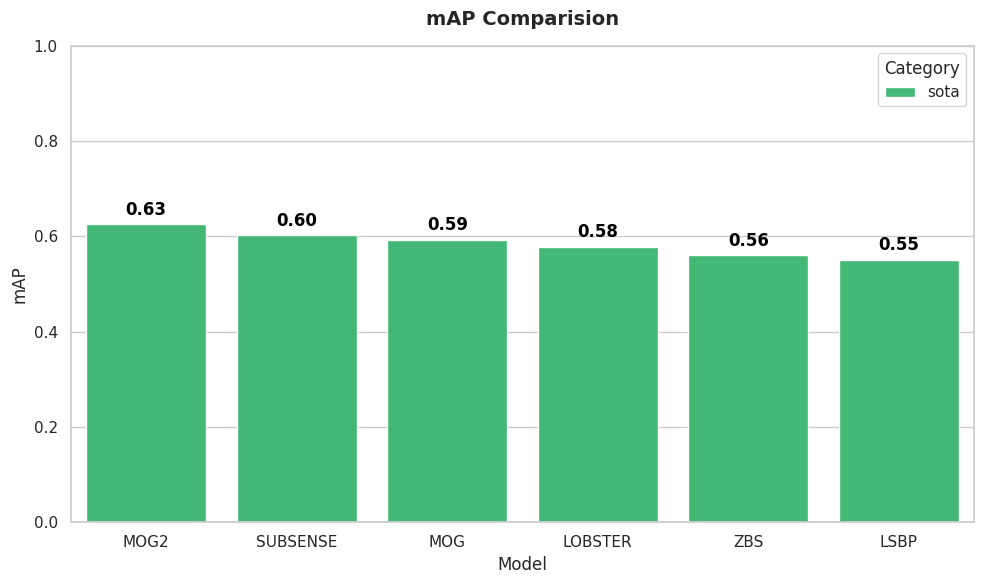

In [9]:
plt.figure(figsize=(10, 6))

# Create a DataFrame for easier handling
df = pd.DataFrame({'Model': models, 'mAP': map_scores, 'Category': categories})
df = df.sort_values('mAP', ascending=False)

# Define specific colors for categories
palette = {"sota": "#2ecc71", "own": "#e67e22"} # Green and Orange

ax = sns.barplot(data=df, x='Model', y='mAP', hue='Category', palette=palette, dodge=False)

for i, v in enumerate(df['mAP']):
    ax.text(i, v + 0.02, f"{v:.2f}", color='black', ha='center', fontweight='bold')

plt.title('mAP Comparision', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Model', fontsize=12)
plt.ylabel('mAP', fontsize=12)
plt.ylim(0, 1) 
plt.legend(title='Category')

plt.tight_layout()
plt.show()

/tmp/ipykernel_543786/3830984506.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sorted_models_time, y=sorted_times, palette="flare")


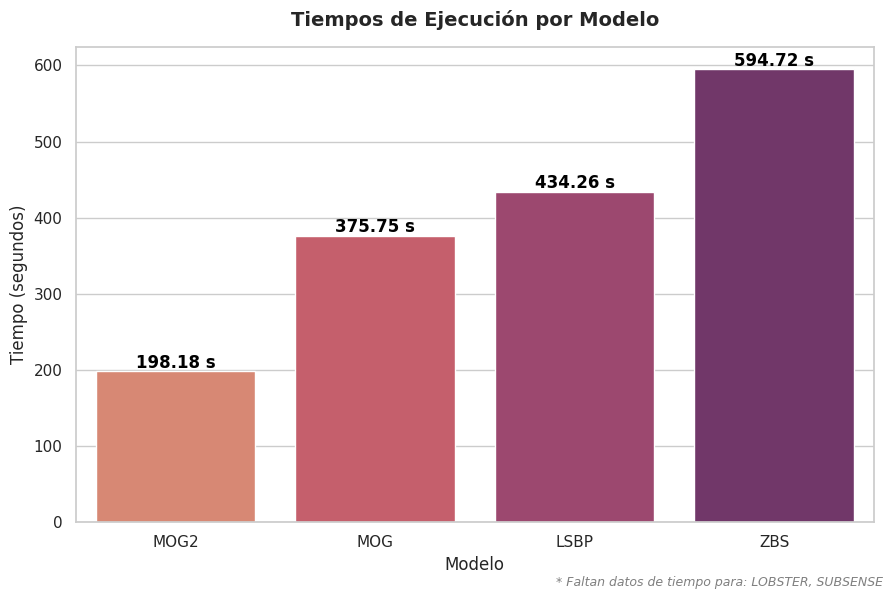

In [ ]:
valid_models = [m for m, t in zip(models, times) if t is not None]
valid_times = [t for t in times if t is not None]

sorted_indices = np.argsort(valid_times)
sorted_models_time = [valid_models[i] for i in sorted_indices]
sorted_times = [valid_times[i] for i in sorted_indices]

plt.figure(figsize=(9, 6))

ax = sns.barplot(x=sorted_models_time, y=sorted_times, palette="flare")

for i, v in enumerate(sorted_times):
    ax.text(i, v + 5, f"{v:.2f} s", color='black', ha='center', fontweight='bold')

plt.title('Tiempos de Ejecución por Modelo', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('Tiempo (segundos)', fontsize=12)

missing_models = [m for m, t in zip(models, times) if t is None]
if missing_models:
    plt.figtext(0.99, 0.01, f"* Faltan datos de tiempo para: {', '.join(missing_models)}", 
                horizontalalignment='right', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.show()